Case Study 1: Hospital Readmission Prediction — Use logistic regression with L2 regularization on patient records (diagnosis codes, vitals, prior visits) to predict 30-day readmission risk. Evaluate with ROC-AUC and discuss clinical cost of false negatives vs. false positives.

> Add blockquote



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

In [ ]:
df = pd.read_csv('/content/diabetic_data.csv')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
# Replace missing values represented by ?
df = df.replace('?', np.nan)

# Target variable
# 1 = Readmitted within 30 days
# 0 = Not readmitted within 30 days

df['target'] = (df['readmitted'] == '<30').astype(int)

# Remove target and identifier columns
X = df.drop(columns=[
    'readmitted',
    'target',
    'encounter_id',
    'patient_nbr'
])

y = df['target']

print("Target Distribution:")
print(y.value_counts())

Target Distribution:
target
0    90409
1    11357
Name: count, dtype: int64


In [ ]:
categorical_columns = X.select_dtypes(
    include=['object']
).columns

numerical_columns = X.select_dtypes(
    exclude=['object']
).columns

print("Categorical Columns:", len(categorical_columns))
print("Numerical Columns:", len(numerical_columns))

Categorical Columns: 36
Numerical Columns: 11


In [ ]:
# Numerical preprocessing
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ('numerical', numerical_pipeline, numerical_columns),
    ('categorical', categorical_pipeline, categorical_columns)
])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (81412, 47)
Testing Data: (20354, 47)


In [ ]:
model = Pipeline([
    ('preprocessor', preprocessor),

    ('classifier', LogisticRegression(
        penalty='l2',
        C=1.0,
        max_iter=1000,
        solver='liblinear',
        class_weight='balanced'
    ))
])

model.fit(X_train, y_train)

print("Model Training Completed!")

Model Training Completed!


In [ ]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions Completed!")

Predictions Completed!


In [ ]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(roc_auc, 4))

ROC-AUC Score: 0.6441


In [ ]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.65      0.76     18083
           1       0.17      0.55      0.25      2271

    accuracy                           0.64     20354
   macro avg       0.54      0.60      0.51     20354
weighted avg       0.84      0.64      0.71     20354



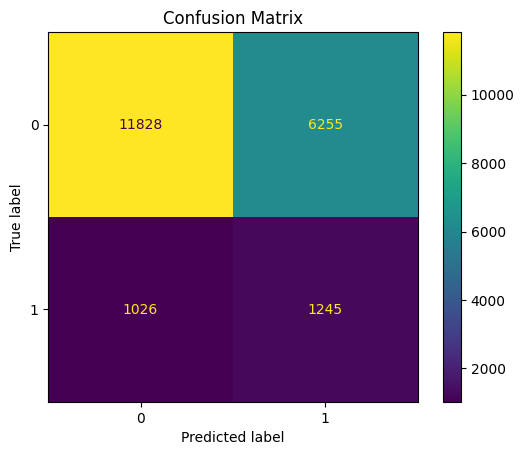

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

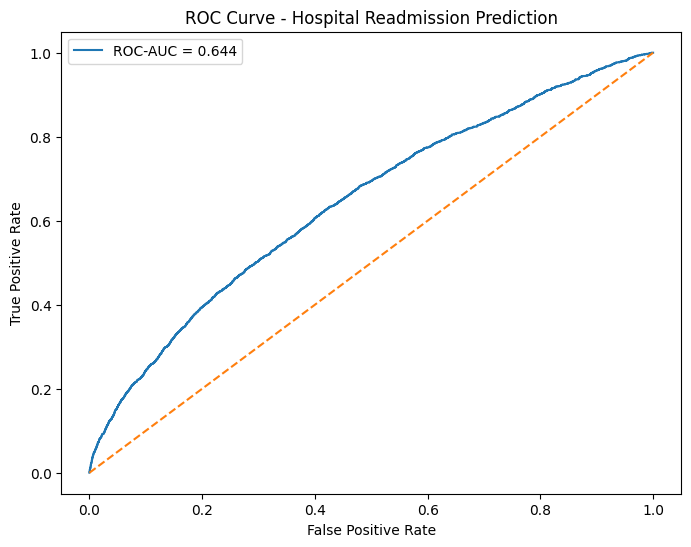

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f'ROC-AUC = {roc_auc:.3f}'
)

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Hospital Readmission Prediction")

plt.legend()
plt.show()

In [ ]:
new_df = pd.DataFrame({'predicted_class': y_pred, 'predicted_proba': y_prob})
new_df.to_csv('predicted_values.csv', index=False)

In [ ]:
from google.colab import files
files.download('predicted_values.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>